# Chunk Stats

Analyzes every `data/processed/file_*/chunks_with_metadata.json` to give a sense of:
- How many chunks per file
- Chunk-size distribution (words, chars)
- Chunk types (text vs image)
- Theme & date coverage
- Empty / suspicious chunks worth filtering

Run from the repo root (or the notebooks/ folder — both work).

In [2]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.9 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 68.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether the notebook runs from /notebooks or repo root.
here = Path.cwd()
REPO_ROOT = here if (here / 'data').exists() else here.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
print(f'Reading chunks from: {PROCESSED_DIR}')

Reading chunks from: /Users/ankitvyas/free-pdf-rag/data/processed


In [4]:
# Load every chunks_with_metadata.json into one flat DataFrame.
rows = []
for folder in sorted(PROCESSED_DIR.glob('file_*')):
    chunks_json = folder / 'chunks_with_metadata.json'
    if not chunks_json.exists():
        continue
    with open(chunks_json) as f:
        chunks = json.load(f)
    for c in chunks:
        meta = c.get('metadata', {}) or {}
        content = c.get('content') or ''
        rows.append({
            'folder': folder.name,
            'source_pdf': c.get('source_pdf') or meta.get('source_pdf') or '',
            'chunk_id': c.get('chunk_id'),
            'chunk_type': c.get('chunk_type', 'text'),
            'title': meta.get('title', ''),
            'date': meta.get('date', ''),
            'theme': meta.get('theme', ''),
            'word_count': c.get('word_count') or len(content.split()),
            'char_count': len(content),
            'is_empty': len(content.strip()) == 0,
            'content_preview': content[:120].replace('\n', ' '),
        })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} chunks from {df["source_pdf"].nunique()} PDFs')
df.head()

Loaded 1113 chunks from 98 PDFs


,folder,source_pdf,chunk_id,chunk_type,title,date,theme,word_count,char_count,is_empty,content_preview
0,file_1,silver_report.pdf,1,text,Has silver entered its “high-speed zone?” One ...,"August 14, 2025",Silver,197,1167,False,What I Learned This Week Share Reading Time: 6...
1,file_1,silver_report.pdf,2,image,Has silver entered its “high-speed zone?” One ...,"August 14, 2025",Silver,66,403,False,The image shows two charts. The left chart dis...
2,file_1,silver_report.pdf,3,text,Has silver entered its “high-speed zone?” One ...,"August 14, 2025",Silver,158,983,False,Our analysis of this week’s U.S. inflation rep...
3,file_1,silver_report.pdf,4,image,Has silver entered its “high-speed zone?” One ...,"August 14, 2025",Silver,117,740,False,The image presents two charts that illustrate ...
4,file_1,silver_report.pdf,5,text,Has silver entered its “high-speed zone?” One ...,"August 14, 2025",Silver,264,1576,False,"Making matters worse, this morning’s wholesale..."


## 1. Chunks per file

In [5]:
per_file = (df.groupby('source_pdf')
              .agg(chunks=('chunk_id', 'count'),
                   text_chunks=('chunk_type', lambda s: (s != 'image').sum()),
                   image_chunks=('chunk_type', lambda s: (s == 'image').sum()),
                   total_words=('word_count', 'sum'),
                   median_words=('word_count', 'median'),
                   empty_chunks=('is_empty', 'sum'))
              .sort_values('chunks', ascending=False))
per_file

,chunks,text_chunks,image_chunks,total_words,median_words,empty_chunks
source_pdf,,,,,,
"August 21, 2025 - Gold Stocks M&A.pdf",36,24,12,4815,109.5,0
"86x, the gold-silver ratio.pdf",34,20,14,4301,97.5,0
"August 14, Silver - High-speed zone.pdf",24,16,8,3987,158.0,0
copper_report.pdf,21,12,9,1869,69.0,0
Mining stocks outperformance.pdf,21,12,9,1512,25.0,0
...,...,...,...,...,...,...
Dutch vs US pregnancies.pdf,4,4,0,1027,278.5,0
Intergenerational Financial Fluency.pdf,4,4,0,984,285.5,0
Trump will make EU great again.pdf,4,4,0,1006,296.5,0


Chunks per file — mean=11.4, median=10, min=3, max=36


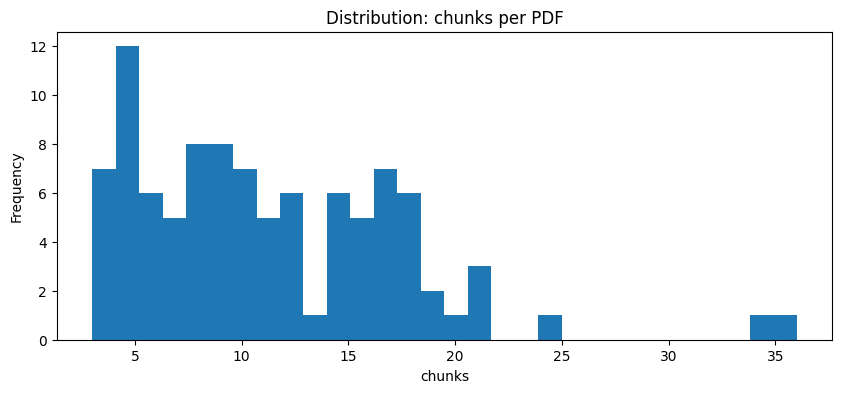

In [6]:
print(f"Chunks per file — mean={per_file['chunks'].mean():.1f}, "
      f"median={per_file['chunks'].median():.0f}, "
      f"min={per_file['chunks'].min()}, max={per_file['chunks'].max()}")

ax = per_file['chunks'].plot.hist(bins=30, figsize=(10, 4))
ax.set_title('Distribution: chunks per PDF')
ax.set_xlabel('chunks')
plt.show()

In [7]:
# Top 15 longest / shortest files (in chunks)
print('--- 15 LARGEST (most chunks) ---')
print(per_file.head(15)[['chunks', 'text_chunks', 'image_chunks']])
print('\n--- 15 SMALLEST ---')
print(per_file.tail(15)[['chunks', 'text_chunks', 'image_chunks']])

--- 15 LARGEST (most chunks) ---
                                                 chunks  text_chunks  \
source_pdf                                                             
August 21, 2025 - Gold Stocks M&A.pdf                36           24   
86x, the gold-silver ratio.pdf                       34           20   
August 14, Silver - High-speed zone.pdf              24           16   
copper_report.pdf                                    21           12   
Mining stocks outperformance.pdf                     21           12   
Nvidia vs Mining Companies.pdf                       21           12   
The bubble of “American exceptionalism”.pdf          20           14   
P2, American exceptionalism finally popping.pdf      19           10   
The Bubble of American exceptionalism.pdf            19           11   
antimony_report.pdf                                  18           11   
USD Index Beakdown.pdf                               18           10   
Oil prices will move higher.pdf

## 2. Chunk-size distribution

count    1113.000000
mean      150.557951
std       115.890509
min         0.000000
10%         3.000000
25%        12.000000
50%       139.000000
75%       277.000000
90%       292.000000
95%       296.000000
99%       300.000000
max       300.000000
Name: word_count, dtype: float64


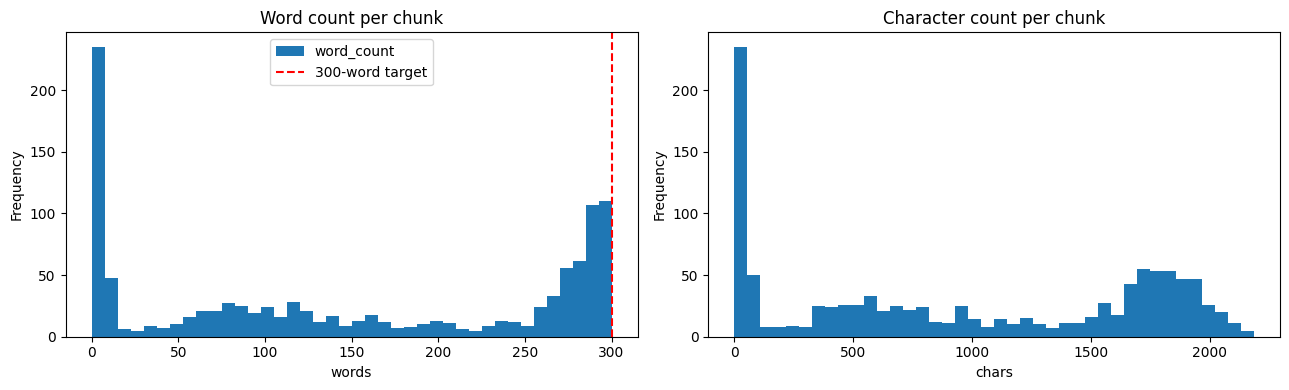

In [8]:
print(df['word_count'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['word_count'].plot.hist(bins=40, ax=axes[0])
axes[0].set_title('Word count per chunk')
axes[0].set_xlabel('words')
axes[0].axvline(300, color='r', linestyle='--', label='300-word target')
axes[0].legend()

df['char_count'].plot.hist(bins=40, ax=axes[1])
axes[1].set_title('Character count per chunk')
axes[1].set_xlabel('chars')
plt.tight_layout()
plt.show()

In [9]:
# How many chunks blow past the 300-word target?
over_300 = (df['word_count'] > 300).sum()
print(f'{over_300} chunks ({over_300/len(df):.1%}) exceed the 300-word combine target')
print(f'Tiny chunks (<20 words): {(df["word_count"] < 20).sum()} ({(df["word_count"] < 20).mean():.1%})')
print(f'Empty content chunks:   {df["is_empty"].sum()} ({df["is_empty"].mean():.1%})')

0 chunks (0.0%) exceed the 300-word combine target
Tiny chunks (<20 words): 285 (25.6%)
Empty content chunks:   22 (2.0%)


## 3. Theme breakdown

In [10]:
by_theme = (df.groupby('theme')
              .agg(chunks=('chunk_id', 'count'),
                   pdfs=('source_pdf', 'nunique'),
                   total_words=('word_count', 'sum'))
              .sort_values('chunks', ascending=False))
by_theme

,chunks,pdfs,total_words
theme,,,
Gold/Gold miners,282,17,32574
Minerals/Metals,137,10,15277
Economy,136,14,19898
Silver,104,5,13081
Tech Arms Race,74,7,13838
Rise of China/Buy China,66,9,11845
Defense & Homeland,54,7,14023
Geopolitics,53,7,11952
Energy,47,3,5209


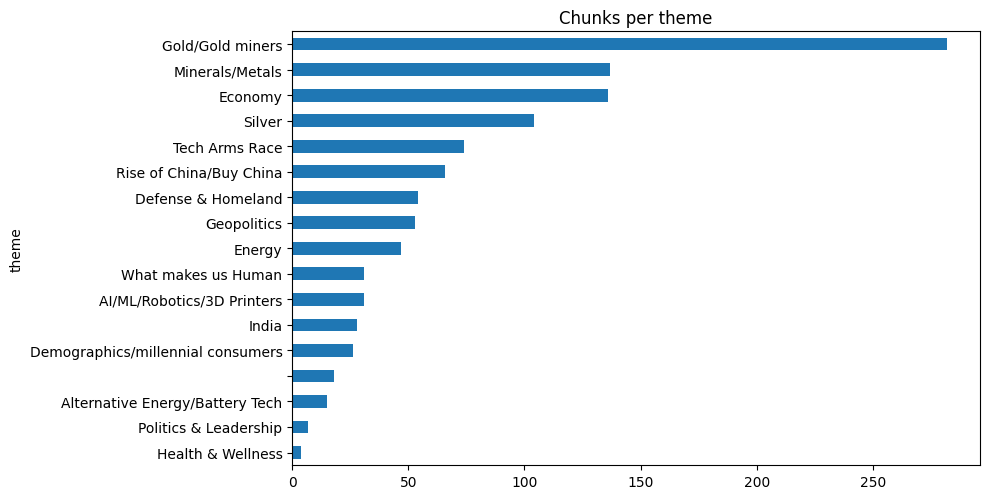

In [11]:
ax = by_theme['chunks'].plot.barh(figsize=(10, max(4, 0.3 * len(by_theme))))
ax.set_title('Chunks per theme')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Chunk-type breakdown (text vs image)

In [12]:
type_counts = df['chunk_type'].value_counts()
print(type_counts)
print(f'\nImage-chunk share: {(df["chunk_type"] == "image").mean():.1%}')

# How many image chunks have empty content (= vision API failed)?
image_df = df[df['chunk_type'] == 'image']
if len(image_df):
    print(f'Empty image chunks: {image_df["is_empty"].sum()} / {len(image_df)} '
          f'({image_df["is_empty"].mean():.1%})')

chunk_type
text     792
image    321
Name: count, dtype: int64

Image-chunk share: 28.8%
Empty image chunks: 22 / 321 (6.9%)


## 5. Date coverage

1113 / 1113 chunks have a parseable date (100.0%)
Date range: 2025-01-09 → 2025-08-21


/var/folders/7w/sc4m0g4531ddfrg03rjtrvtm0000gn/T/ipykernel_38353/3682927952.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq='M'))


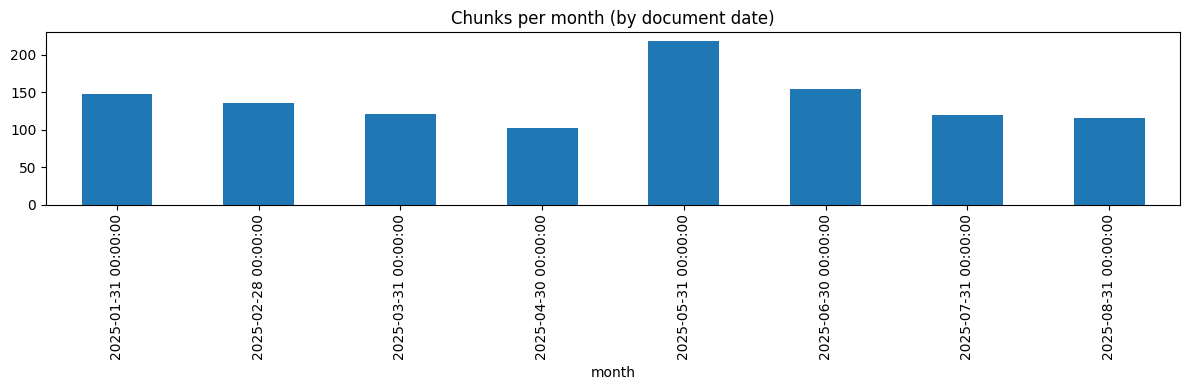

In [13]:
df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce')
date_cov = df.dropna(subset=['parsed_date'])
print(f'{len(date_cov)} / {len(df)} chunks have a parseable date '
      f'({len(date_cov)/len(df):.1%})')
print(f'Date range: {date_cov["parsed_date"].min().date()} → {date_cov["parsed_date"].max().date()}')

if len(date_cov):
    by_month = (date_cov.set_index('parsed_date')
                        .groupby(pd.Grouper(freq='M'))
                        .size())
    ax = by_month.plot.bar(figsize=(12, 4))
    ax.set_title('Chunks per month (by document date)')
    ax.set_xlabel('month')
    plt.tight_layout()
    plt.show()

## 6. Metadata health checks

Anything below should ideally be 0 — surfaces silent ingestion problems.

In [14]:
checks = {
    'missing source_pdf': (df['source_pdf'] == '').sum(),
    'missing title':      (df['title'] == '').sum(),
    'missing date':       (df['date'] == '').sum(),
    'missing theme':      (df['theme'] == '').sum(),
    'empty content':      df['is_empty'].sum(),
    'tiny chunks (<20w)': (df['word_count'] < 20).sum(),
    'huge chunks (>500w)': (df['word_count'] > 500).sum(),
}
pd.Series(checks, name='count').to_frame()

,count
missing source_pdf,0
missing title,0
missing date,0
missing theme,18
empty content,22
tiny chunks (<20w),285
huge chunks (>500w),0


In [15]:
# Inspect the empty chunks — usually image-marker chunks the vision API failed on.
df[df['is_empty']][['source_pdf', 'chunk_id', 'chunk_type', 'date']].head(30)

,source_pdf,chunk_id,chunk_type,date
386,antimony_report.pdf,6,image,"May 8, 2025"
390,antimony_report.pdf,10,image,"May 8, 2025"
416,Global capital reallocation.pdf,2,image,"June 26, 2025"
430,"Gold Prices, Southern Cross Gold.pdf",6,image,"May 8, 2025"
434,"Gold Prices, Southern Cross Gold.pdf",10,image,"May 8, 2025"
438,"Gold Prices, Southern Cross Gold.pdf",14,image,"May 8, 2025"
549,Is “U.S. exceptionalism” now “The Mother of Al...,10,image,"February 13, 2025"
667,Oil prices will move higher.pdf,4,image,"July 24, 2025"
775,Silver mining stocks.pdf,2,image,"May 1, 2025"
842,The Bubble of American exceptionalism.pdf,4,image,"May 22, 2025"


## 7. Vocab / lexical signals (cheap)

Catches duplicate or near-duplicate chunks and shows the most common tokens — useful for spotting noise like boilerplate footers.

In [16]:
from collections import Counter
import re

def tokens(s):
    return re.findall(r'[a-z]{3,}', (s or '').lower())

all_tokens = Counter()
for c in df['content_preview']:
    all_tokens.update(tokens(c))
print('Top 25 tokens across chunk previews:')
print(pd.Series(dict(all_tokens.most_common(25))))

Top 25 tokens across chunk previews:
the        1071
and         340
this        251
source      225
that        189
week        165
what        153
share       153
learned     141
for         140
time        138
are         114
reading     108
minutes     107
listen      107
audio       107
with         97
gold         93
has          92
have         82
image        76
from         71
china        71
silver       68
global       66
dtype: int64


In [17]:
# Exact-duplicate detection on content_preview (first 120 chars).
# A high count here suggests boilerplate or repeated headers/footers.
dup_counts = (df[df['content_preview'].str.len() > 30]
                .groupby('content_preview').size()
                .sort_values(ascending=False))
print(f'Top repeated chunk previews:')
dup_counts.head(15)

Top repeated chunk previews:


content_preview
Source: Bloomberg and 13D Research & Strategy                                                                               4
Source: The Silver Institute, World Silver Survey                                                                           4
After the pit-wall event, the company reduced its expected production target by 13% at Camino Rojo, but this translated     3
We disagree with this consensus view, and have spent considerable time analyzing and outlining the fiscal and monetary d    3
In WILTW May 1, 2025, we wrote that investment demand for silver is the biggest short-term wild card.  So far, this year    3
What I Learned This Week Share Reading Time: 8 minutes  Listen to Audio (14:47) This year’s S&P Global analysis of gold    3
The 2025 YTD gain alone is more than four times the 17% gain logged in the second half of the 1970s, and not far from th    3
But historically, “the small-caps make the majority of the discoveries because they take greater risk,

## 8. Save summary to disk

Drops a CSV next to the chunks so you can grep / share without re-running the notebook.

In [18]:
out = PROCESSED_DIR / '_chunk_stats_per_file.csv'
per_file.to_csv(out)
print(f'Wrote {out}')

Wrote /Users/ankitvyas/free-pdf-rag/data/processed/_chunk_stats_per_file.csv
